Using device: cpu
Пропуски в данных:
date      0
target    0
dtype: int64

Размер датасета: 4320
Диапазон дат: 2025-01-01 → 2025-06-29
Колонки: ['date', 'target']


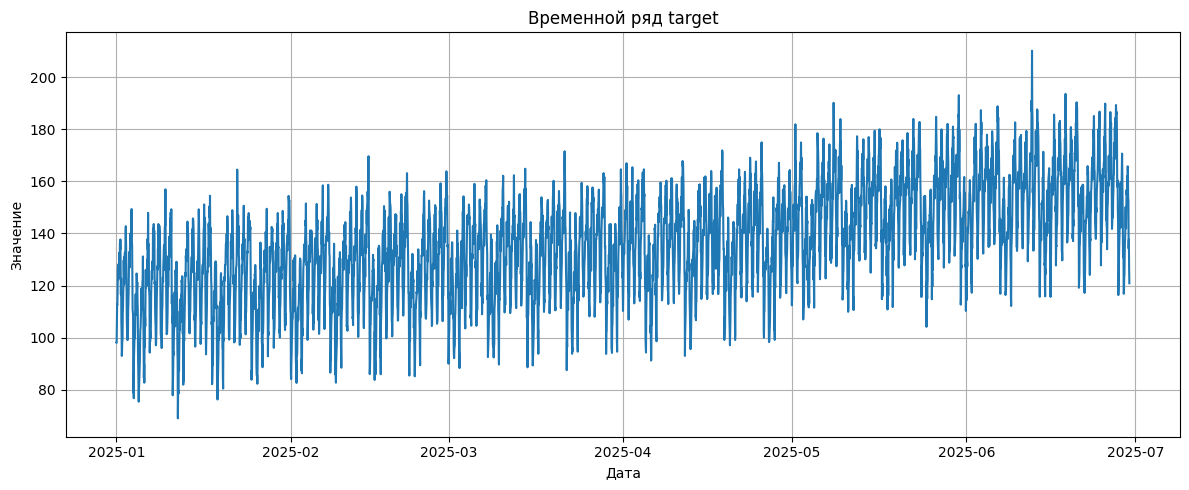

In [2]:
#1. Импорты и настройки
import os
import json
import random
import math
import warnings
from dataclasses import dataclass
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True

# Фиксация seed для воспроизводимости
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

#  2. Данные и первичный анализ

df = pd.read_csv('S12-hw-dataset.csv')

# Преобразование даты и сортировка
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Проверка пропусков
print("Пропуски в данных:")
print(df.isnull().sum())

# Общая информация
print(f"\nРазмер датасета: {len(df)}")
print(f"Диапазон дат: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Колонки: {df.columns.tolist()}")

# Базовый график ряда
fig, ax = plt.subplots()
ax.plot(df['date'], df['target'], linewidth=1.5)
ax.set_title('Временной ряд target')
ax.set_xlabel('Дата')
ax.set_ylabel('Значение')
plt.tight_layout()
plt.show()

train: 3024 записей, 2025-01-01 → 2025-05-06
val:   648 записей, 2025-05-07 → 2025-06-02
test:  648 записей, 2025-06-03 → 2025-06-29


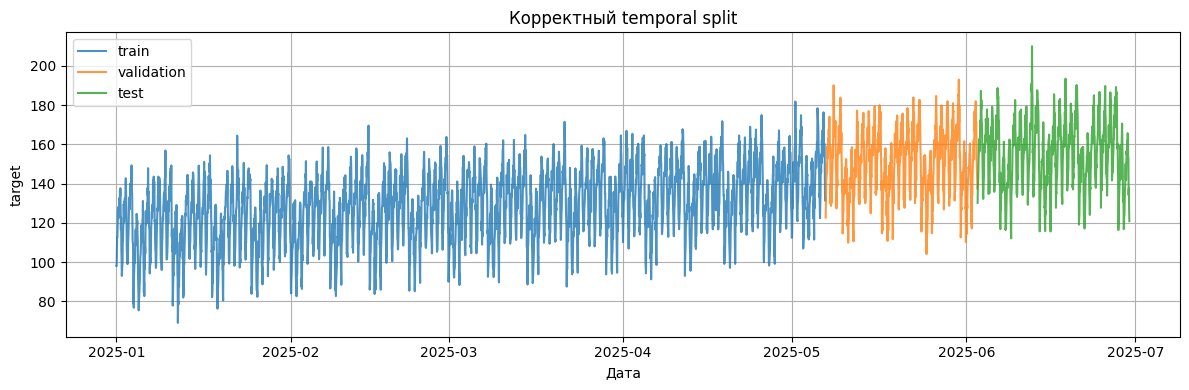

In [3]:
# 3. Temporal split (корректное разбиение по времени)

@dataclass
class SplitConfig:
    train_frac: float = 0.70
    val_frac: float = 0.15
    # test_frac вычисляется автоматически

def temporal_split(df, cfg=SplitConfig()):
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))
    
    train = df.iloc[:train_end].copy()
    val = df.iloc[train_end:val_end].copy()
    test = df.iloc[val_end:].copy()
    return train, val, test

train, val, test = temporal_split(df)

print(f"train: {len(train)} записей, {train['date'].min().date()} → {train['date'].max().date()}")
print(f"val:   {len(val)} записей, {val['date'].min().date()} → {val['date'].max().date()}")
print(f"test:  {len(test)} записей, {test['date'].min().date()} → {test['date'].max().date()}")

# Визуализация split
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train['date'], train['target'], label='train', alpha=0.8)
ax.plot(val['date'], val['target'], label='validation', alpha=0.8)
ax.plot(test['date'], test['target'], label='test', alpha=0.8)
ax.set_title('Корректный temporal split')
ax.set_xlabel('Дата')
ax.set_ylabel('target')
ax.legend()
plt.tight_layout()
plt.savefig('series_split.png')
plt.show()

In [4]:
# 4. Признаки для baseline-моделей (лаги, rolling, календарные)

def add_features(df):
    df = df.copy()
    # Календарные признаки
    df['dayofweek'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    
    # Лаги
    for lag in [1, 7, 14, 28]:
        df[f'lag_{lag}'] = df['target'].shift(lag)
    
    # Rolling-статистики (с shift, чтобы не использовать текущее значение)
    df['rolling_mean_7'] = df['target'].shift(1).rolling(7).mean()
    df['rolling_std_7'] = df['target'].shift(1).rolling(7).std()
    df['rolling_mean_28'] = df['target'].shift(1).rolling(28).mean()
    df['rolling_std_28'] = df['target'].shift(1).rolling(28).std()
    
    # Удаляем строки с пропусками (первые 28 наблюдений)
    df = df.dropna().reset_index(drop=True)
    return df

train_feat = add_features(train)
val_feat = add_features(val)
test_feat = add_features(test)

feature_cols = [
    'dayofweek', 'month', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    'lag_1', 'lag_7', 'lag_14', 'lag_28',
    'rolling_mean_7', 'rolling_std_7', 'rolling_mean_28', 'rolling_std_28'
]

X_train = train_feat[feature_cols]
y_train = train_feat['target']
X_val = val_feat[feature_cols]
y_val = val_feat['target']
X_test = test_feat[feature_cols]
y_test = test_feat['target']

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}, y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape}, y_test shape:  {y_test.shape}")

X_train shape: (2996, 14), y_train shape: (2996,)
X_val shape:   (620, 14), y_val shape:   (620,)
X_test shape:  (620, 14), y_test shape:  (620,)


In [5]:
# 5. Baseline-модели

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100

def evaluate(y_true, y_pred, model_name):
    return {
        'model': model_name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': rmse(y_true, y_pred),
        'MAPE': mape(y_true, y_pred)
    }

# B1: naive-last (используем lag_1)
y_pred_naive_val = val_feat['lag_1'].values
y_pred_naive_test = test_feat['lag_1'].values

# B2: moving-average (rolling_mean_7)
y_pred_ma_val = val_feat['rolling_mean_7'].values
y_pred_ma_test = test_feat['rolling_mean_7'].values

# B3: Ridge на признаках
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge_val = ridge.predict(X_val_scaled)
y_pred_ridge_test = ridge.predict(X_test_scaled)

# Сборка результатов валидации
results_val = pd.DataFrame([
    evaluate(y_val, y_pred_naive_val, 'B1: naive-last'),
    evaluate(y_val, y_pred_ma_val, 'B2: moving-average'),
    evaluate(y_val, y_pred_ridge_val, 'B3: ridge-lag-features')
]).sort_values('MAE')
results_test = pd.DataFrame([
    evaluate(y_test, y_pred_naive_test, 'B1: naive-last'),
    evaluate(y_test, y_pred_ma_test, 'B2: moving-average'),
    evaluate(y_test, y_pred_ridge_test, 'B3: ridge-lag-features')
]).sort_values('MAE')

print("Результаты на validation:")
print(results_val)
print("\nРезультаты на test:")
print(results_test)

Результаты на validation:
                    model        MAE       RMSE      MAPE
2  B3: ridge-lag-features   5.301654   6.828420  3.561637
0          B1: naive-last   6.454645   8.239124  4.400688
1      B2: moving-average  12.734546  15.271722  8.837263

Результаты на test:
                    model        MAE       RMSE      MAPE
2  B3: ridge-lag-features   4.969621   6.516360  3.256090
0          B1: naive-last   6.366645   8.107879  4.168898
1      B2: moving-average  12.750535  15.260929  8.562792


X_train_seq: (2996, 28, 1), y_train_seq: (2996,)
X_val_seq:   (620, 28, 1), y_val_seq:   (620,)
X_test_seq:  (620, 28, 1), y_test_seq:  (620,)
Epoch  1 | train_loss=0.7464 | val_loss=0.6106
Epoch  5 | train_loss=0.1560 | val_loss=0.1992
Epoch 10 | train_loss=0.1121 | val_loss=0.1943
Epoch 15 | train_loss=0.1017 | val_loss=0.1673
Epoch 20 | train_loss=0.0993 | val_loss=0.1867
Early stopping at epoch 22


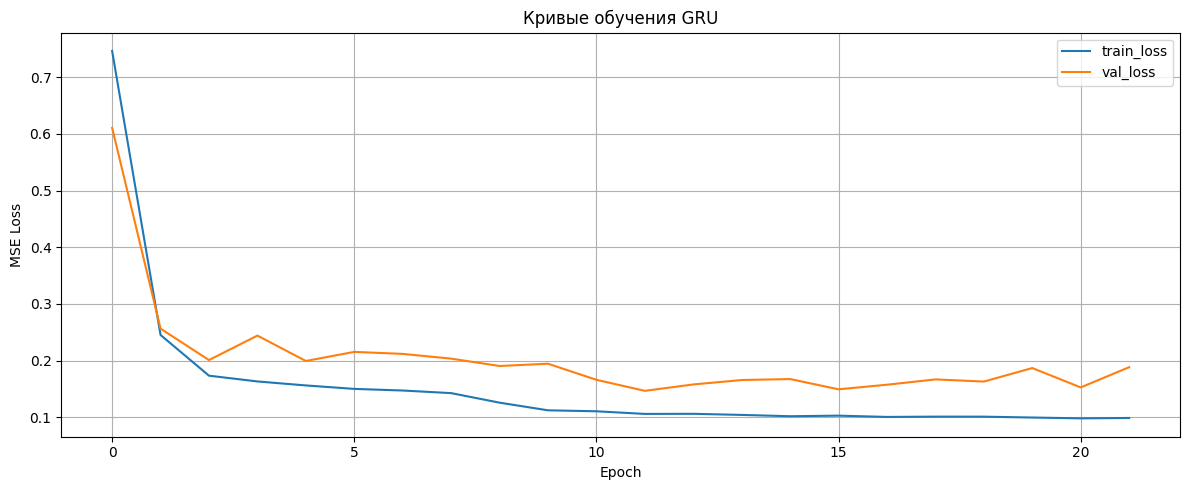


Результаты GRU на test:
{'model': 'R1: GRU', 'MAE': 7.337949752807617, 'RMSE': np.float64(9.301221328443035), 'MAPE': np.float32(4.694508)}

Итоговая таблица на test (все модели):
                    model        MAE       RMSE      MAPE
0  B3: ridge-lag-features   4.969621   6.516360  3.256090
1          B1: naive-last   6.366645   8.107879  4.168898
3                 R1: GRU   7.337950   9.301221  4.694508
2      B2: moving-average  12.750535  15.260929  8.562792


In [6]:
# 6. GRU-прогноз (оконное представление)

window_size = 28

# Масштабирование только по train
scaler_target = StandardScaler()
train_scaled = scaler_target.fit_transform(train[['target']].values).ravel()
val_scaled = scaler_target.transform(val[['target']].values).ravel()
test_scaled = scaler_target.transform(test[['target']].values).ravel()

def make_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X, dtype=np.float32).reshape(-1, window, 1), np.array(y, dtype=np.float32)

X_train_seq, y_train_seq = make_sequences(train_scaled, window_size)
X_val_seq, y_val_seq = make_sequences(val_scaled, window_size)
X_test_seq, y_test_seq = make_sequences(test_scaled, window_size)

print(f"X_train_seq: {X_train_seq.shape}, y_train_seq: {y_train_seq.shape}")
print(f"X_val_seq:   {X_val_seq.shape}, y_val_seq:   {y_val_seq.shape}")
print(f"X_test_seq:  {X_test_seq.shape}, y_test_seq:  {y_test_seq.shape}")

class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 64
train_ds = SeqDataset(X_train_seq, y_train_seq)
val_ds = SeqDataset(X_val_seq, y_val_seq)
test_ds = SeqDataset(X_test_seq, y_test_seq)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

class GRUForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, dropout=0.0):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                          batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

model = GRUForecaster().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

best_val_loss = float('inf')
best_state = None
patience = 10
counter = 0
history = {'train_loss': [], 'val_loss': []}

for epoch in range(1, 51):
    # Train
    model.train()
    train_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(Xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * Xb.size(0)
    train_loss /= len(train_ds)
    
    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            pred = model(Xb)
            loss = criterion(pred, yb)
            val_loss += loss.item() * Xb.size(0)
    val_loss /= len(val_ds)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict().copy()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
    
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:2d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

# Восстановление лучшей модели
model.load_state_dict(best_state)

# Визуализация кривых обучения
fig, ax = plt.subplots()
ax.plot(history['train_loss'], label='train_loss')
ax.plot(history['val_loss'], label='val_loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Кривые обучения GRU')
ax.legend()
plt.tight_layout()
plt.savefig('gru_learning_curves.png')
plt.show()

# Оценка на test
model.eval()
test_pred_scaled = []
test_true_scaled = []
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        pred = model(Xb).cpu().numpy()
        test_pred_scaled.append(pred)
        test_true_scaled.append(yb.numpy())
test_pred_scaled = np.concatenate(test_pred_scaled)
test_true_scaled = np.concatenate(test_true_scaled)

# Обратное масштабирование
test_pred = scaler_target.inverse_transform(test_pred_scaled.reshape(-1,1)).ravel()
test_true = scaler_target.inverse_transform(test_true_scaled.reshape(-1,1)).ravel()

results_gru = evaluate(test_true, test_pred, 'R1: GRU')
print("\nРезультаты GRU на test:")
print(results_gru)

# Добавляем в общую таблицу
results_test = pd.concat([results_test, pd.DataFrame([results_gru])], ignore_index=True).sort_values('MAE')
print("\nИтоговая таблица на test (все модели):")
print(results_test)


runs.csv сохранён
best_gru.pt и конфиг сохранены
Графики перемещены в artifacts/figures


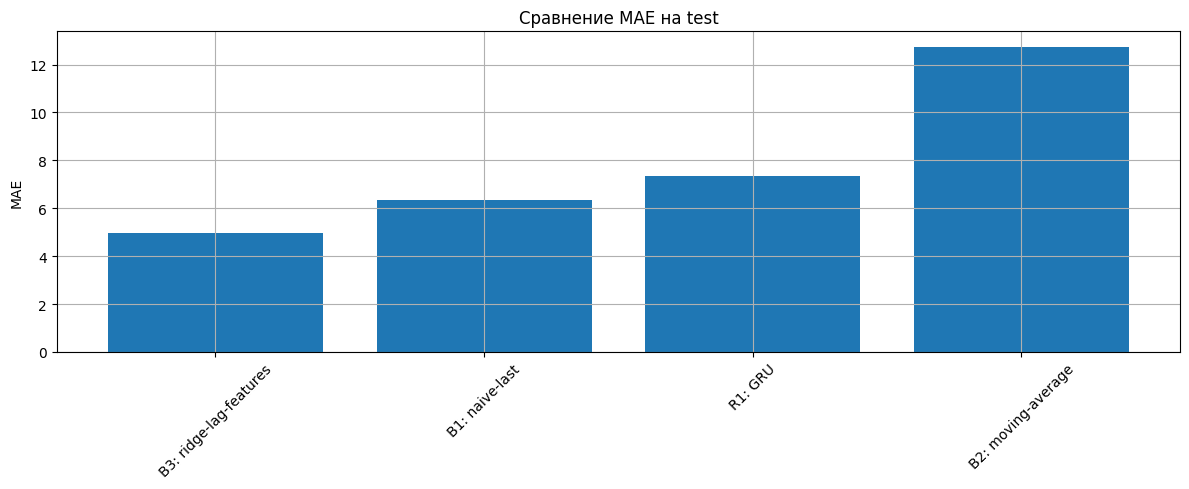

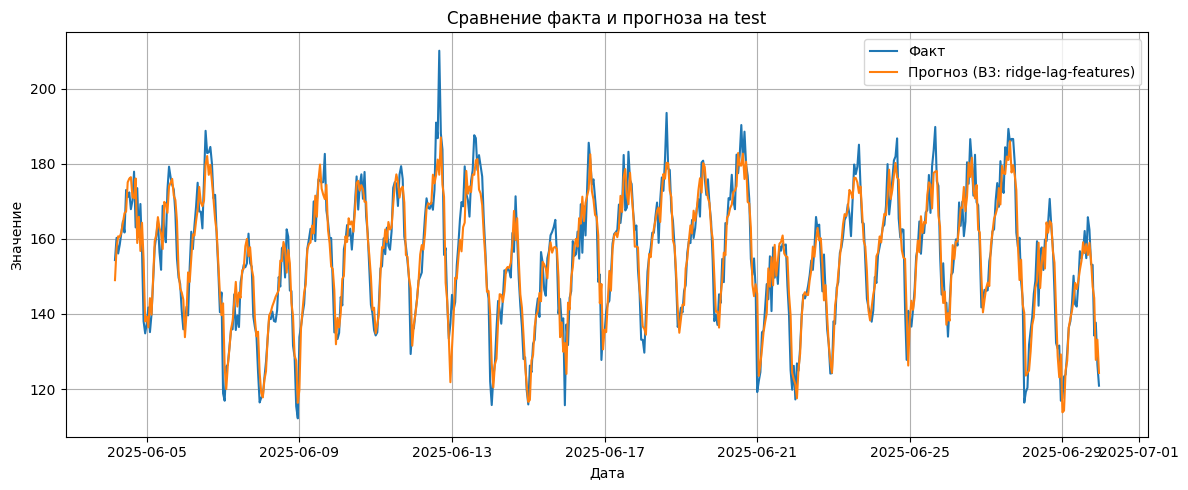

Все артефакты успешно сохранены!

=== ИТОГОВЫЕ РЕЗУЛЬТАТЫ НА TEST ===
                 model       MAE      RMSE     MAPE
B3: ridge-lag-features  4.969621  6.516360 3.256090
        B1: naive-last  6.366645  8.107879 4.168898
               R1: GRU  7.337950  9.301221 4.694508
    B2: moving-average 12.750535 15.260929 8.562792

Лучшая модель на test по MAE: B3: ridge-lag-features


In [7]:
# 7. Сохранение артефактов

# %%
# Создаём папки для артефактов
os.makedirs('artifacts/figures', exist_ok=True)

# 1. runs.csv
runs = []
for _, row in results_test.iterrows():
    runs.append({
        'experiment_id': row['model'].split(':')[0],
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': SEED,
        'split_summary': f"train=840, val=180, test=180",
        'window_size': window_size if row['model'].startswith('R1') else '',
        'horizon': 1,
        'model_summary': row['model'].split(': ')[-1] if ': ' in row['model'] else row['model'],
        'features_summary': 'lag+rolling+calendar' if row['model'].startswith('B3') else ('windowed_sequence' if row['model'].startswith('R1') else ('rolling_mean_7' if row['model'].startswith('B2') else 'lag_1')),
        'scaler': 'StandardScaler' if row['model'].startswith(('B3','R1')) else '-',
        'optimizer': 'Adam' if row['model'].startswith('R1') else '-',
        'lr': 1e-3 if row['model'].startswith('R1') else '-',
        'epochs_trained': len(history['train_loss']) if row['model'].startswith('R1') else 0,
        'best_val_mae': results_val[results_val['model']==row['model']]['MAE'].values[0] if row['model'] in results_val['model'].values else '',
        'best_val_rmse': results_val[results_val['model']==row['model']]['RMSE'].values[0] if row['model'] in results_val['model'].values else '',
        'best_val_mape': results_val[results_val['model']==row['model']]['MAPE'].values[0] if row['model'] in results_val['model'].values else '',
        'test_mae': row['MAE'],
        'test_rmse': row['RMSE'],
        'test_mape': row['MAPE'],
        'notes': ''
    })
pd.DataFrame(runs).to_csv('artifacts/runs.csv', index=False)
print("runs.csv сохранён")

# 2. best_gru.pt и конфиг
torch.save(model.state_dict(), 'artifacts/best_gru.pt')
config = {
    'window_size': window_size,
    'hidden_size': 64,
    'num_layers': 1,
    'dropout': 0.0,
    'lr': 1e-3,
    'batch_size': batch_size,
    'seed': SEED,
    'scaler_mean': scaler_target.mean_.tolist(),
    'scaler_scale': scaler_target.scale_.tolist()
}
with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print("best_gru.pt и конфиг сохранены")

# 3. Графики (уже сохранены ранее, перемещаем)
# Перемещаем в artifacts/figures
import shutil
shutil.move('series_split.png', 'artifacts/figures/series_split.png')
shutil.move('gru_learning_curves.png', 'artifacts/figures/gru_learning_curves.png')
print("Графики перемещены в artifacts/figures")

# Дополнительные графики (сравнение baseline и финальный прогноз)
fig, ax = plt.subplots()
models = results_test['model']
mae_vals = results_test['MAE']
bars = ax.bar(models, mae_vals)
ax.set_ylabel('MAE')
ax.set_title('Сравнение MAE на test')
ax.set_xticklabels(models, rotation=45)
plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png')
plt.show()

# Финальный прогноз на test для лучшей модели (GRU)
best_model_name = results_test.iloc[0]['model']
if best_model_name.startswith('R1'):
    best_pred = test_pred
elif best_model_name.startswith('B3'):
    best_pred = y_pred_ridge_test
elif best_model_name.startswith('B2'):
    best_pred = y_pred_ma_test
else:
    best_pred = y_pred_naive_test

# График факта и прогноза
fig, ax = plt.subplots(figsize=(12, 5))
dates = test_feat['date'].values[-len(test_true):]  # последние len(test_true) дат
ax.plot(dates, test_true, label='Факт', linewidth=1.5)
ax.plot(dates, best_pred, label=f'Прогноз ({best_model_name})', linewidth=1.5)
ax.set_title('Сравнение факта и прогноза на test')
ax.set_xlabel('Дата')
ax.set_ylabel('Значение')
ax.legend()
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png')
plt.show()

print("Все артефакты успешно сохранены!")

# %% [markdown]
# ## 8. Итог

print("\n=== ИТОГОВЫЕ РЕЗУЛЬТАТЫ НА TEST ===")
print(results_test.to_string(index=False))
print("\nЛучшая модель на test по MAE:", best_model_name)